In [2]:
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
import pandas as pd
import pygmt

read the dataset and organize the columns

In [3]:
df = pd.read_csv('..\\..\\data\\age_hf\\lat_long_q_age.txt', sep='\t', header=None, 
                 names=['lat', 'lon', 'q', 'age'])
print(df.head())

     lat     lon      q       age
0  49.62 -129.98  366.0  0.816961
1  44.68 -125.29   79.0  9.119624
2  44.66 -125.27   81.0  9.119624
3  44.66 -125.27   93.0  9.119624
4  44.66 -125.26   77.0  9.119624


now for pars-scl, we get depth from formula 21 and heat flow from formula 23... and for stein x2 we get depth and heat flow from pg 126

In [4]:
ihfc_qt = []
sqrt_age = []
ps_qt = []
dt_ps = []
stein_qt = []
dt_stein = []

# ihfc
for q in df['q']:
    ihfc_qt.append(q*0.0238846)  # mW/m^2 --> μcal/cm^2*s

# pars-scl
for a in df['age']:
    sqrt_age.append(a**(0.5))
    dt_ps.append(2500 + 350*(a**(0.5)))
    ps_qt.append(11.3/a**(0.5))

# stein x2
for a in df['age']:
    dt_stein.append(2600+365*a**2)
    stein_qt.append((510/a**(0.5))*0.0239)  # mW/m^2 --> μcal/cm^2*s

print(f'pars-scl depth: {dt_ps[:2]}, stein depth: {dt_stein[:2]}, sqrt(age): {sqrt_age[:2]}')
print(f'ihfc heat flow: {ihfc_qt[:2]}, pars-scl heat flow: {ps_qt[:2]}, stein heat flow: {stein_qt[:2]}')

pars-scl depth: [2816.350676741808, 3556.955037951], stein depth: [2843.610362732936, 32956.15345973479], sqrt(age): [0.9038590764051662, 3.019871537002857]
ihfc heat flow: [8.741763599999999, 1.8868833999999999], pars-scl heat flow: [12.501948915468581, 3.741881024255407], stein heat flow: [13.485509321296153, 4.036264407491076]


> fig 10 from pars-scl

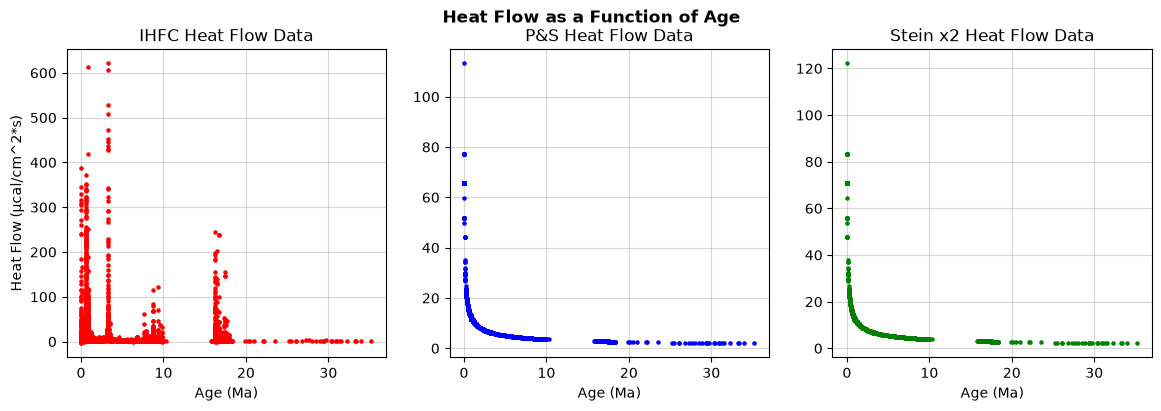

In [6]:
fig, (ax0, ax1, ax2) = plt.subplots(1, 3, figsize=(14, 4))

ax0.scatter(df['age'], ihfc_qt, marker='o', color='red', s=5)
ax0.set_xlabel('Age (Ma)')
ax0.set_ylabel('Heat Flow (μcal/cm^2*s)')
ax0.set_title('IHFC Heat Flow Data')
ax0.set_axisbelow(True)
ax0.grid(alpha=0.5)

ax1.scatter(df['age'], ps_qt, marker='o',color='blue', s=5)
ax1.set_xlabel('Age (Ma)')
# ax1.set_ylabel('Heat Flow (μcal/cm^2*s)')
ax1.set_title('P&S Heat Flow Data')
ax1.set_axisbelow(True)
ax1.grid(alpha=0.5)

ax2.scatter(df['age'], stein_qt, marker='o',color='green', s=5)
ax2.set_xlabel('Age (Ma)')
# ax1.set_ylabel('Heat Flow (μcal/cm^2*s)')
ax2.set_title('Stein x2 Heat Flow Data')
ax2.set_axisbelow(True)
plt.grid(alpha=0.5)

fig.suptitle('Heat Flow as a Function of Age', fontweight='bold')


plt.show()

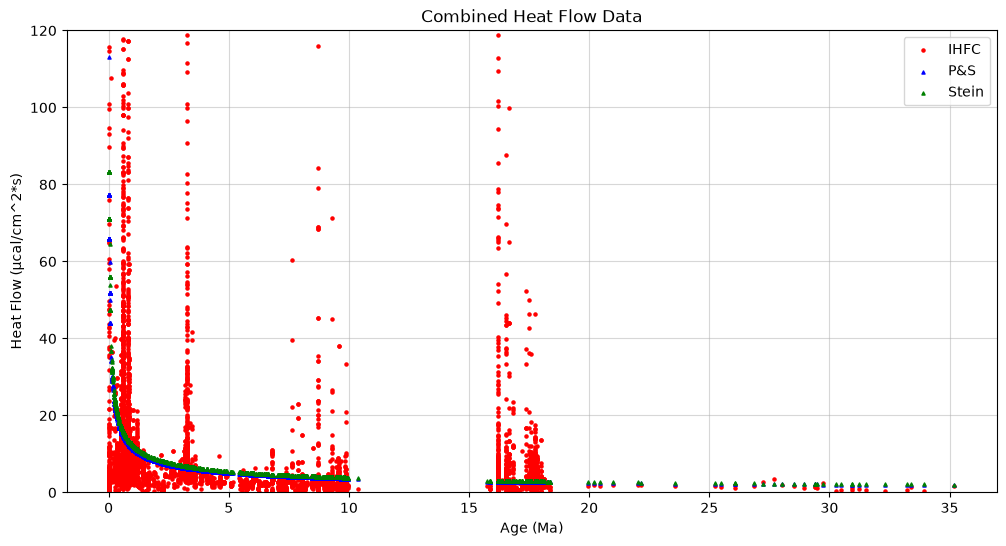

In [7]:
fig1, ax3 = plt.subplots(figsize=(12, 6))

ax3.scatter(df['age'], ihfc_qt, marker='o',color='red', s=5, label='IHFC')
ax3.scatter(df['age'], ps_qt, marker='^', color='blue', s=5, label='P&S')
ax3.scatter(df['age'], stein_qt, marker='^', color='green', s=5, label='Stein')
ax3.set_ylim(0, 120)
ax3.set_xlabel('Age (Ma)')
ax3.set_ylabel('Heat Flow (μcal/cm^2*s)')
ax3.set_title('Combined Heat Flow Data')
ax3.set_axisbelow(True)

plt.grid(alpha=0.5)
plt.legend()
plt.show()

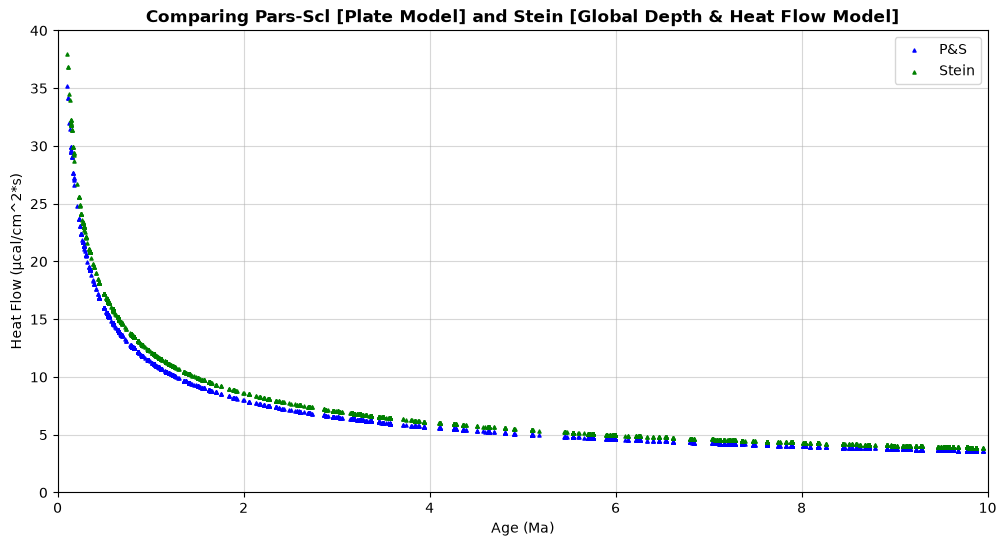

In [8]:
fig2, ax4 = plt.subplots(figsize=(12, 6))

ax4.scatter(df['age'], ps_qt, marker='^', color='blue', s=5, label='P&S')
ax4.scatter(df['age'], stein_qt, marker='^', color='green', s=5, label='Stein')
ax4.set_ylim(0, 40)
ax4.set_xlim(0, 10)
ax4.set_xlabel('Age (Ma)')
ax4.set_ylabel('Heat Flow (μcal/cm^2*s)')
ax4.set_title('Comparing Pars-Scl [Plate Model] and Stein [Global Depth & Heat Flow Model]', fontweight='bold')
ax4.set_axisbelow(True)

plt.grid(alpha=0.5)
plt.legend()
plt.show()